Quadratic coefficients: A=0.18493463058680412, B=-5.264235329887497, C=88.29545454545452
Quadratic values at x: [83.21615385 78.50672241 74.16716023 70.19746732 66.59764366 63.36768927
 60.50760413 58.01738826 55.89704165 54.14656431 52.76595622 51.75521739
 51.11434783 50.84334752 50.94221648 51.4109547  52.24956218 53.45803892
 55.03638492 56.98460018 59.30268471 61.99063849 65.04846154 68.47615385]
Quadratic values at fine x: [83.21615385 83.16722868 83.1183405  ... 68.40397528 68.44004607
 68.47615385]
E2 error: 13.128567186703897
Spline values at fine x: [75.         75.03975189 75.07905598 ... 71.88050429 71.94012794
 72.        ]
Fitted parameters: A=14.612184882900886, B=0.2145359661321861, C=62.98773619486074
Cosine values at fine x: [77.26494097 77.25823423 77.25146181 ... 69.10811592 69.13656782
 69.16499143]
E2 error for cosine model: 6.130596283826543


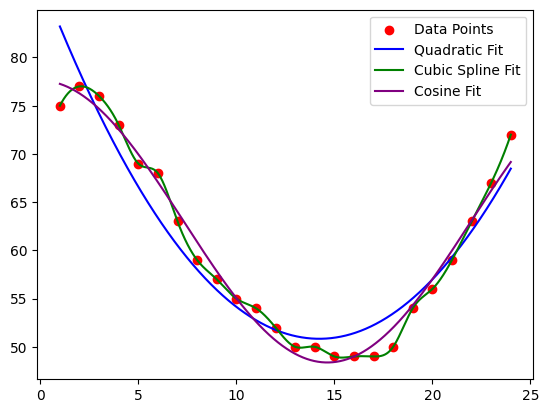

In [19]:
import numpy as np

x = np.arange(1, 25)  # hours 1 through 24

y = np.array([75, 77, 76, 73, 69, 68, 63, 59, 57, 55, 54, 52, 50, 50, 49, 49, 49, 50, 54, 56, 59, 63, 67, 72])

[A, B, C] = np.polyfit(x, y, 2)

print(f"Quadratic coefficients: A={A}, B={B}, C={C}")

# evaluates the quadratic at each x value
quadratic_values = np.polyval([A, B, C], x)

print(f"Quadratic values at x: {quadratic_values}")

# But the values that we get are discrete and we want a smooth curve, so we can use a finer grid of x values
x_fine = np.arange(1.0, 24.01, 0.01)
quadratic_values_fine = np.polyval([A, B, C], x_fine)
print(f"Quadratic values at fine x: {quadratic_values_fine}")

# plot the original data points and the quadratic curve
import matplotlib.pyplot as plt

# We can see that the quadratic curve fits the data points reasonably well, but is still not great.
# To calculate the E2 error we can use np
E2 = np.linalg.norm(y - quadratic_values)

print(f"E2 error: {E2}")


# Use interp1d and spline command to get a better fit
from scipy.interpolate import interp1d, CubicSpline

# Create a cubic spline interpolation of the data points
cs = CubicSpline(x, y)

# Evaluate the cubic spline at the fine x values
spline_values_fine = cs(x_fine)
print(f"Spline values at fine x: {spline_values_fine}")


# Now we need to work with y = A cos(Bx) + C, which is a non-linear model, polyfit won't work here

from scipy.optimize import curve_fit


def cosine_model(x, A, B, C):
    return A * np.cos(B * x) + C

# Now to estimate the guesses we need to look at the data

# The Amplitude of our data can be estimate as (77 - 49) / 2 = 14, so we can use A = 14 as an initial guess
A_guess = 14

# The vertical off set can be a the average of the max and min values, so we can use C = (77 + 49) / 2 = 63 as an initial guess
C_guess = (77 + 49) / 2

# B is changing the frequency of the cosine
# so we can estimate the period of the data, which is the time it takes for the data to complete one full cycle.
# From the data we can see that the period is around 24 hours, so we can use B = 2 * pi / 24 as an initial guess
B_guess = 2 * np.pi / 24

# Fit the cosine model to the data
params, covariance = curve_fit(cosine_model, x, y, p0=[A_guess, B_guess, C_guess])  # Initial guess for A, B, C

A_fit, B_fit, C_fit = params

print(f"Fitted parameters: A={A_fit}, B={B_fit}, C={C_fit}")

# Evaluate the fitted cosine model at the fine x values
cosine_values_fine = cosine_model(x_fine, A_fit, B_fit, C_fit)
print(f"Cosine values at fine x: {cosine_values_fine}")

# And to calculate the E2 error for the cosine model we can use np.linalg.norm again
cosine_values = cosine_model(x, A_fit, B_fit, C_fit)
E2_cosine = np.linalg.norm(y - cosine_values)
print(f"E2 error for cosine model: {E2_cosine}")

# Plot the original data points, the quadratic curve, the cubic spline, and the fitted cosine model
plt.scatter(x, y, color='red', label='Data Points')
plt.plot(x_fine, quadratic_values_fine, color='blue', label='Quadratic Fit')
plt.plot(x_fine, spline_values_fine, color='green', label='Cubic Spline Fit')
plt.plot(x_fine, cosine_values_fine, color='purple', label='Cosine Fit')
plt.legend()
plt.show()

Fitted parameters: A=1.930610416528093, B=0.13461261374324748, C=0.8788906301070307, D=29.681994738475435
Fitted values at x: [31.61260516 32.47403032 33.30084054 34.09397814 34.85499466 35.58602281
 36.28973791 36.96930944 37.62834372 38.27081867 38.9010118  39.52342284
 40.14269234 40.76351767 41.39056806 42.02840012 42.68137536 43.35358133
 44.0487576  44.77022816 45.52084125 46.30291781 47.11820953 47.96786712
 48.85241948 49.77176419 50.7251693  51.71128661 52.72817603 53.77334073
 54.84377228]
E2 error for fitted model: 11.983897963524223
Fitted parameters with new guesses: A=-1.9101662688276788, B=0.7510347566698911, C=0.7109310804116142, D=31.816371724228496
E2 error for fitted model with new guesses: 9.684600279018815
E2 error for my fitted model: 0.0
Fitted parameters for Fourier model: A1=-1.9127045523092807, B1=0.7506540479955774, A2=-0.5054343501739383, B2=1.524166710443833, C=0.7106615702685343, D=31.836107838248648
E2 error for Fourier fitted model: 9.478356249562884


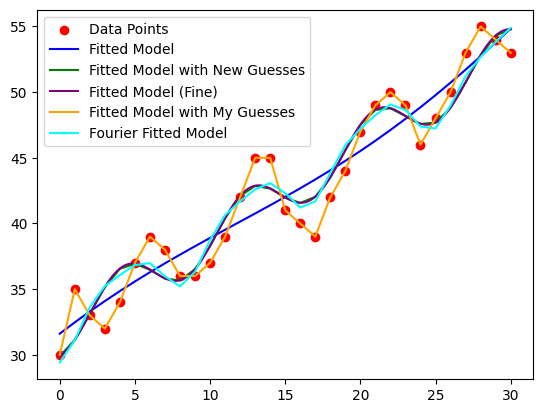

In [54]:
import numpy as np

v = np.array([30, 35, 33, 32, 34, 37, 39, 38, 36, 36, 37, 39, 42, 45, 45, 41, 40, 39, 42, 44, 47, 49, 50,
49, 46, 48, 50, 53, 55, 54, 53])

x = np.arange(0, 31)  # 0 to 30 seconds (match v length)

#  The function we will work now is f(t) = Acos(Bt)+Ct+D
def cosine_model_with_offset(t, A, B, C, D):
    return A * np.cos(B * t) + C * t + D

# To estimate the initial guesses for A, B, C, D we can look at the data
A_guess = (55 - 30) / 2  # Amplitude
C_guess = (55 + 30) / 2  # Vertical offset
B_guess = 2 * np.pi / 30  # Frequency
D_guess = 0  # Linear term

# Fit the cosine model with offset to the data
params, covariance = curve_fit(cosine_model_with_offset, x, v, p0=[A_guess, B_guess, C_guess, D_guess])

A_fit, B_fit, C_fit, D_fit = params

print(f"Fitted parameters: A={A_fit}, B={B_fit}, C={C_fit}, D={D_fit}")

# Evaluate the fitted model at the x values
fitted_values = cosine_model_with_offset(x, A_fit, B_fit, C_fit, D_fit)
print(f"Fitted values at x: {fitted_values}")

# Calculate the E2 error for the fitted model
E2_fitted = np.linalg.norm(v - fitted_values)
print(f"E2 error for fitted model: {E2_fitted}")

#  Now using the guesses as A,B,C and D being 3,π/4,2/3 and 32 respectively
A_guess = 3
B_guess = np.pi / 4
C_guess = 2 / 4
D_guess = 2

params, covariance = curve_fit(cosine_model_with_offset, x, v, p0=[A_guess, B_guess, C_guess, D_guess])
A_fit, B_fit, C_fit, D_fit = params
print(f"Fitted parameters with new guesses: A={A_fit}, B={B_fit}, C={C_fit}, D={D_fit}")

new_fitted_values = cosine_model_with_offset(x, A_fit, B_fit, C_fit, D_fit)
E2_new_fitted = np.linalg.norm(v - new_fitted_values)
print(f"E2 error for fitted model with new guesses: {E2_new_fitted}")

#  trying spline interpolation again with the new data points, but this time we will use the original x values and the fitted values from the cosine model as the y values for the spline interpolation
from scipy.interpolate import CubicSpline
cs = CubicSpline(x, v)
my_fitted_values = cs(x)
E2_my_fitted = np.linalg.norm(v - my_fitted_values)
print(f"E2 error for my fitted model: {E2_my_fitted}")

# Also trying Fourier series fitting to see if we can get a better model
def fourier_model(t, A1, B1, A2, B2, C, D):
    return A1*np.cos(B1*t) + A2*np.cos(B2*t) + C*t + D

A1_guess = 3
B1_guess = np.pi / 4
A2_guess = 1
B2_guess = np.pi / 2
C_guess = 2 / 4
D_guess = 2

params, covariance = curve_fit(fourier_model, x, v, p0=[A1_guess, B1_guess, A2_guess, B2_guess, C_guess, D_guess])
A1_fit, B1_fit, A2_fit, B2_fit, C_fit, D_fit = params

print(f"Fitted parameters for Fourier model: A1={A1_fit}, B1={B1_fit}, A2={A2_fit}, B2={B2_fit}, C={C_fit}, D={D_fit}")
fourier_fitted_values = fourier_model(x, A1_fit, B1_fit, A2_fit, B2_fit, C_fit, D_fit)
E2_fourier_fitted = np.linalg.norm(v - fourier_fitted_values)
print(f"E2 error for Fourier fitted model: {E2_fourier_fitted}")

#  Least-square curve for t = 0 ∶ 0.01 ∶ 30 - so pretty much a smoother curve than the one we get with the original x values
t_fine = np.arange(0, 30.01, 0.01)
fitted_values_fine = cosine_model_with_offset(t_fine, A_fit, B_fit, C_fit, D_fit)

# Plot the original data points and the fitted model
import matplotlib.pyplot as plt
plt.scatter(x, v, color='red', label='Data Points')
plt.plot(x, fitted_values, color='blue', label='Fitted Model')
plt.plot(x, new_fitted_values, color='green', label='Fitted Model with New Guesses')
plt.plot(t_fine, fitted_values_fine, color='purple', label='Fitted Model (Fine)')
plt.plot(x, my_fitted_values, color='orange', label='Fitted Model with My Guesses')
plt.plot(x, fourier_fitted_values, color='cyan', label='Fourier Fitted Model')
plt.legend()
plt.show()